In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# need to do it in google collab

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os

print(os.path.exists("/content/drive/MyDrive/fruits.zip"))

True


In [1]:

!wget https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip

--2026-07-12 05:27:06--  https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip
Resolving bitbucket.org (bitbucket.org)... 13.200.41.135, 13.200.41.136, 13.200.41.134, ...
Connecting to bitbucket.org (bitbucket.org)|13.200.41.135|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-07-12 05:27:07 ERROR 404: Not Found.



In [6]:
!unzip -q "/content/drive/MyDrive/fruits.zip" -d "/content/fruits"

In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt



In [8]:
tf.__version__

'2.20.0'

In [18]:
img_height,img_width = 32,32
batch_size=20

train_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/fruits/fruits/train',
    image_size = (img_height,img_width),
    batch_size=batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/fruits/fruits/validation',
   image_size = (img_height,img_width),
    batch_size=batch_size
)

test_ds = tf.keras.utils.image_dataset_from_directory(
   '/content/fruits/fruits/test',
  image_size = (img_height,img_width),
    batch_size=batch_size
)



Found 460 files belonging to 3 classes.
Found 66 files belonging to 3 classes.
Found 130 files belonging to 3 classes.


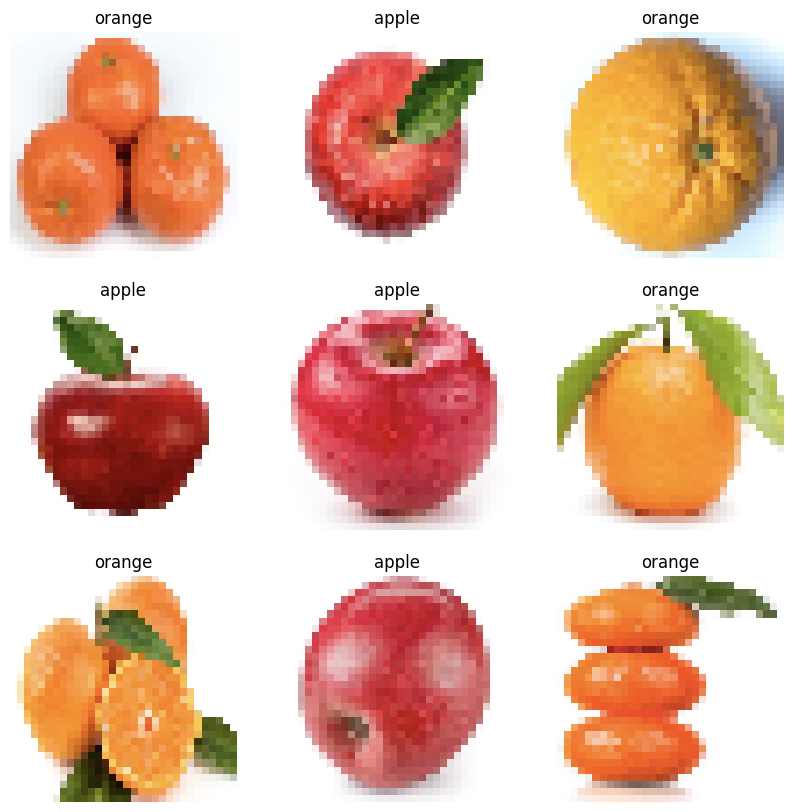

In [19]:
class_names = ["apple","banana","orange"]
plt.figure(figsize=(10,10))

for images,labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [20]:
model=tf.keras.Sequential(
    [tf.keras.layers.Rescaling(1./255),
     tf.keras.layers.Conv2D(32,3,activation='relu'),
     tf.keras.layers.MaxPooling2D(),
     tf.keras.layers.Conv2D(64,3,activation='relu'),
     tf.keras.layers.MaxPooling2D(),
     tf.keras.layers.Conv2D(128,3,activation='relu'),
     tf.keras.layers.MaxPooling2D(),
     tf.keras.layers.Flatten(),
     tf.keras.layers.Dense(128,activation='softmax'),
     tf.keras.layers.Dense(3)
     ]
)

In [27]:
model.compile(
    optimizer="rmsprop",
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'])

In [28]:
model.fit(train_ds,validation_data=val_ds,epochs=20)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.3413 - loss: 1.0982 - val_accuracy: 0.3333 - val_loss: 1.0947
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.4283 - loss: 1.0850 - val_accuracy: 0.5758 - val_loss: 1.0502
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.5370 - loss: 1.0336 - val_accuracy: 0.5303 - val_loss: 0.9906
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.5478 - loss: 0.9923 - val_accuracy: 0.6364 - val_loss: 0.9786
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.6348 - loss: 0.9666 - val_accuracy: 0.6061 - val_loss: 0.9526
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.7087 - loss: 0.9463 - val_accuracy: 0.5303 - val_loss: 0.9978
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.7674 - loss: 0.9142 - val_accuracy: 0.7424 - val_loss: 0.9026
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.7609 - loss: 0.9113 - val_accuracy: 0.6970

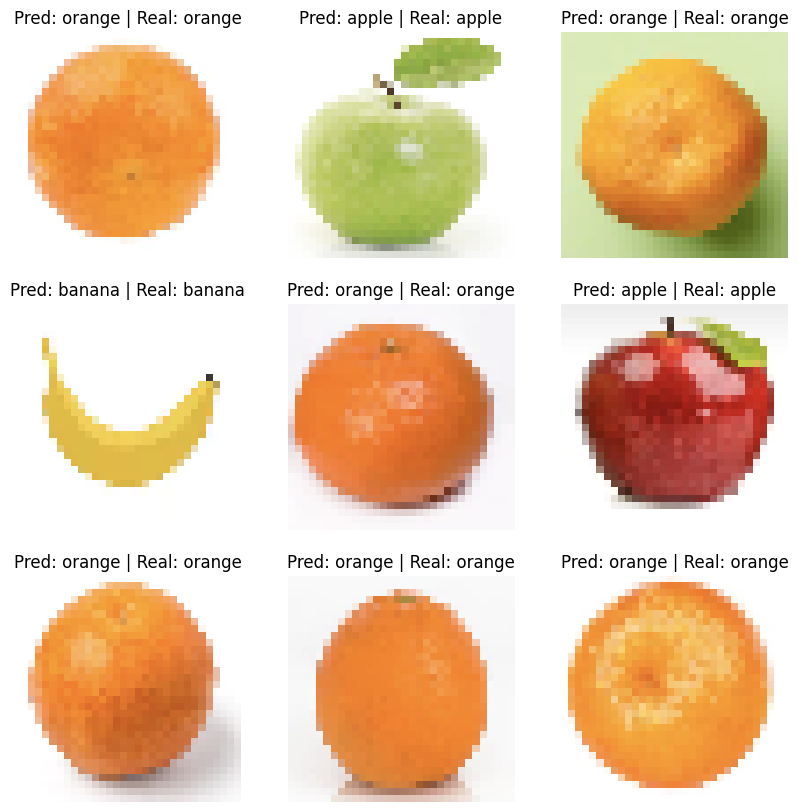

In [31]:
import numpy

plt.figure(figsize=(10,10))
for images,labels in test_ds.take(1):
  classifications= model(images)
  #print(classifications)

  for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    index = numpy.argmax(classifications[i])
    plt.title("Pred: " + class_names[index] + " | Real: " + class_names[labels[i]])
    plt.axis("off")